<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import random

In [58]:
df = sns.load_dataset('diamonds').copy()

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [60]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [61]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [62]:
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [63]:
son_null= df.isnull().sum()
son_null

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [64]:
encoder = OrdinalEncoder(categories=[
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    ['J', 'I', 'H', 'G', 'F', 'E', 'D'],
    ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
])
df[['cut', 'color', 'clarity']] = encoder.fit_transform(df[['cut', 'color', 'clarity']])

In [77]:
numeros_desordenados= random.sample(range(1, 31),5)

In [65]:
x= df.drop(columns=['price'])

In [66]:
y= df['price']

In [67]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

In [68]:
sc= StandardScaler()
x_train_esc= sc.fit_transform(x_train)
x_test_esc= sc.transform(x_test)

In [69]:
m_5= KNeighborsRegressor(n_neighbors=5)
m_5.fit(x_train_esc, y_train)
r2_5= m_5.score(x_test_esc, y_test)
r2_5

0.9680536942075302

In [70]:
m_5= KNeighborsRegressor(n_neighbors= 4)
m_5.fit(x_train_esc, y_train)
r2_4= m_5.score(x_test_esc, y_test)
r2_4

0.9676081476881502

In [71]:
m_5= KNeighborsRegressor(n_neighbors= 3)
m_5.fit(x_train_esc, y_train)
r2_3= m_5.score(x_test_esc, y_test)
r2_3

0.9662523665488065

In [72]:
m_5= KNeighborsRegressor(n_neighbors=2)
m_5.fit(x_train_esc, y_train)
r2_2= m_5.score(x_test_esc, y_test)
r2_2

0.9635627405460746

In [73]:
m_5= KNeighborsRegressor(n_neighbors=1)
m_5.fit(x_train_esc, y_train)
r2_1= m_5.score(x_test_esc, y_test)
r2_1

0.9539186617872784

In [74]:
y_pred_5 = m_5.predict(x_test_esc)

print(f'\nMejor modelo (k=5):')
print(f'  R²:   {r2_score(y_test, y_pred_5):.4f}')
print(f'  MAE:  ${mean_absolute_error(y_test, y_pred_5):.0f}')
print(f'  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_5)):.0f}')


Mejor modelo (k=5):
  R²:   0.9539
  MAE:  $432
  RMSE: $856


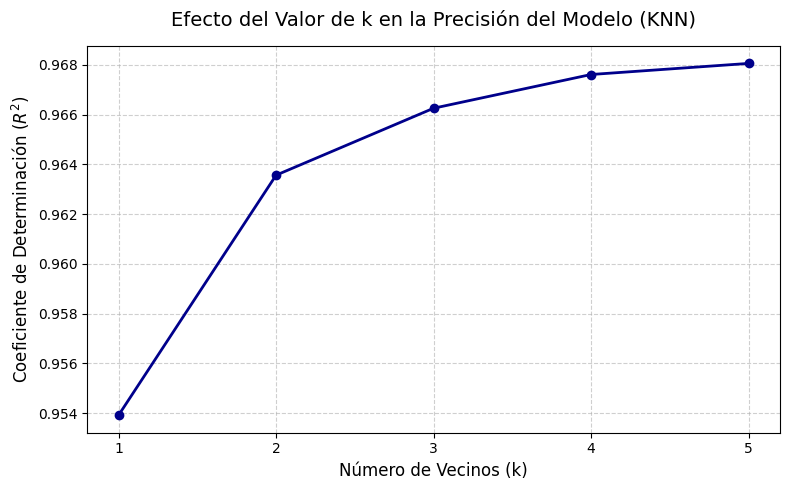

In [75]:
lista_k = [1, 2, 3, 4, 5]
lista_r2 = [r2_1, r2_2, r2_3, r2_4, r2_5]

# Configuración del gráfico
plt.figure(figsize=(8, 5))
plt.plot(lista_k, lista_r2, marker='o', linestyle='-', color='darkblue', linewidth=2)

# Títulos y etiquetas
plt.title('Efecto del Valor de k en la Precisión del Modelo (KNN)', fontsize=14, pad=15)
plt.xlabel('Número de Vecinos (k)', fontsize=12)
plt.ylabel('Coeficiente de Determinación ($R^2$)', fontsize=12)

# Ajuste de los ejes para que muestre exactamente nuestros valores de k
plt.xticks(lista_k)
plt.grid(True, linestyle='--', alpha=0.6)

# Desplegar el gráfico en pantalla
plt.tight_layout()
plt.show()